In [ ]:
"""
這段程式碼跑出來的結果是「含息總報酬」，也就是包含了「價差 + 配息再投資」的結果，而不僅僅是價格差異。
關鍵在於 Adj Close (還原收盤價)
在程式碼中，我們提取的是 raw_data[ticker]['Adj Close']。
   # Close (收盤價)：僅反映市場交易價格。當 ETF 除息時，股價會跳空下跌，這欄位會顯示跌價，導致看起來報酬變差。
   # Adj Close (還原收盤價)：這是金融數據（如 Yahoo Finance）經過數學計算後的數值。它會把歷年來的配息金額自動補回股價中，並假設你領到配息後，立刻以當天價格再買入該標的。
因此，當你計算 Adj Close 的漲跌幅時，它代表的是：如果你持有一份資產，且每次領到股息都自動滾入再投資，到今天為止的資產總市值變化。
"""

# 0050 vs 00878

[*********************100%***********************]  2 of 2 completed


=== 最新累計報酬率 ===
               0050.TW    00878.TW
Date                              
2026-05-25  392.631230  187.559345
2026-05-26  389.210158  188.924972
2026-05-27  401.183855  197.996537
2026-05-28  391.165051  192.631631
2026-05-29  415.112409  200.044968


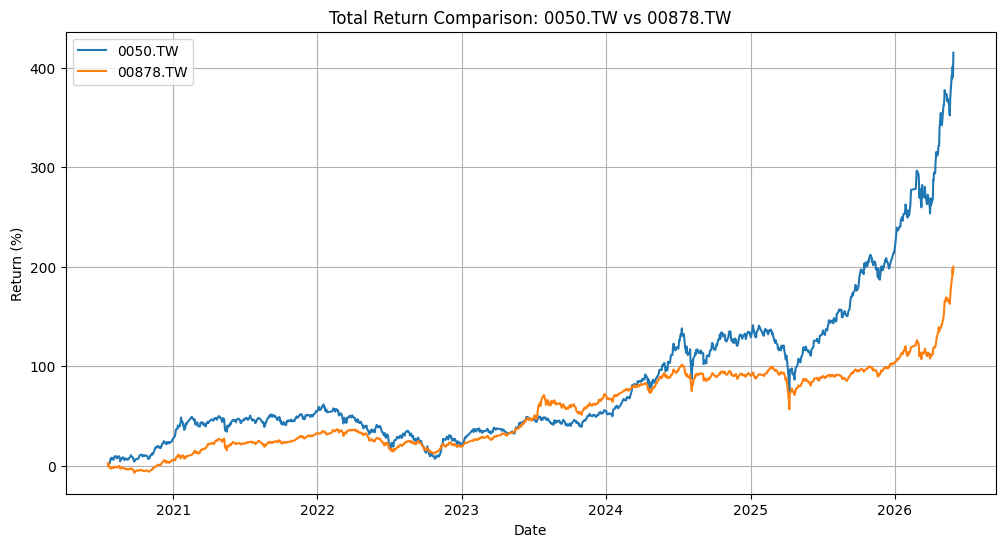

In [2]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# ==================== 設定區 ====================
# 你可以自由把 '00878.TW' 換成 '00919.TW'
high_dividend_ticker = '00878.TW' 
market_ticker = '0050.TW'

# 定義各別的上市日期（用作動態起點）
launch_dates = {
    '00878.TW': '2020-07-20',
    '00919.TW': '2022-10-20'
}

start_date = launch_dates[high_dividend_ticker]
end_date = '2026-06-01'  # 或設定為今天
# ================================================

# 1. 下載資料：明確設定 group_by='ticker' 讓資料依股票代號分組，並關閉自動調整
tickers = [market_ticker, high_dividend_ticker]
raw_data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=False, group_by='ticker')

"""
這段程式碼跑出來的結果是「含息總報酬」，也就是包含了「價差 + 配息再投資」的結果，而不僅僅是價格差異。
關鍵在於 Adj Close (還原收盤價)
在程式碼中，我們提取的是 raw_data[ticker]['Adj Close']。
   # Close (收盤價)：僅反映市場交易價格。當 ETF 除息時，股價會跳空下跌，這欄位會顯示跌價，導致看起來報酬變差。
   # Adj Close (還原收盤價)：這是金融數據（如 Yahoo Finance）經過數學計算後的數值。它會把歷年來的配息金額自動補回股價中，並假設你領到配息後，立刻以當天價格再買入該標的。
因此，當你計算 Adj Close 的漲跌幅時，它代表的是：如果你持有一份資產，且每次領到股息都自動滾入再投資，到今天為止的資產總市值變化。
"""


# 2. 安全地提取兩檔 ETF 的 'Adj Close' 欄位，組成新的 DataFrame
data = pd.DataFrame({
    market_ticker: raw_data[market_ticker]['Adj Close'],
    high_dividend_ticker: raw_data[high_dividend_ticker]['Adj Close']
})

# 3. 為了公平比較，將起點的價格全部「歸一化（Normalize）」為 1（或 100）
# 這樣代表兩者在第一天投入相同金額的資產變化
normalized_data = data / data.iloc[0]

# 4. 計算累計報酬率 (%)
cum_return = (normalized_data - 1) * 100
print("=== 最新累計報酬率 ===")
print(cum_return.tail()) 

# 5. 繪製趨勢圖比較
plt.figure(figsize=(12, 6))
plt.plot(cum_return.index, cum_return[market_ticker], label=market_ticker)
plt.plot(cum_return.index, cum_return[high_dividend_ticker], label=high_dividend_ticker)
plt.title(f'Total Return Comparison: {market_ticker} vs {high_dividend_ticker}')
plt.ylabel('Return (%)')
plt.xlabel('Date')
plt.legend()
plt.grid(True)
plt.show()

# 0050 vs 0056、00878、00919

[*********************100%***********************]  4 of 4 completed


=== 最新累計報酬率 ===
               0050.TW     0056.TW    00878.TW    00919.TW
Date                                                      
2026-05-25  349.051183  180.108599  155.054552  155.953451
2026-05-26  345.932752  179.934805  156.265813  160.239540
2026-05-27  356.847210  187.582029  164.311957  168.811698
2026-05-28  347.714708  182.889428  159.553483  164.711966
2026-05-29  369.543591  190.826315  166.128840  170.302507


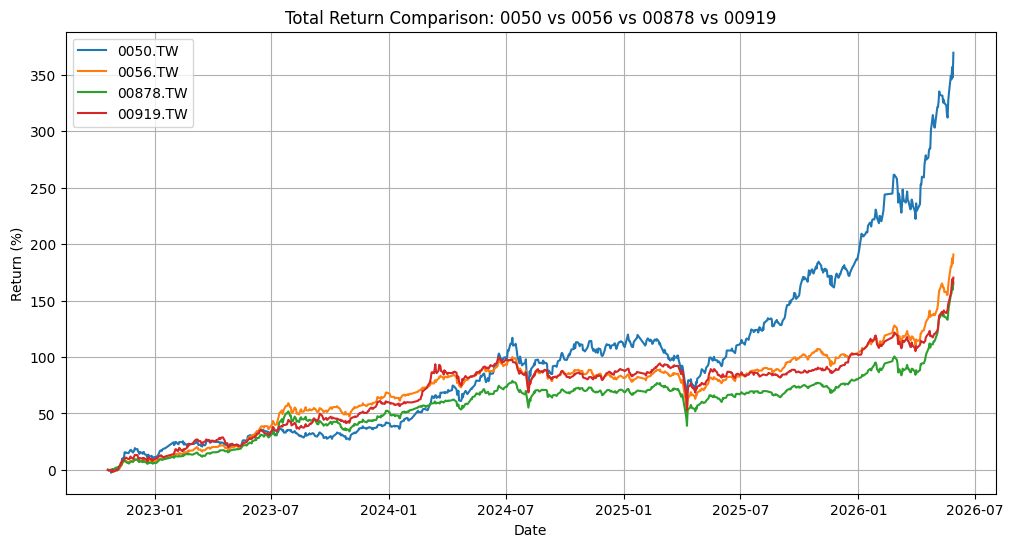

In [1]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# ==================== 設定區 ====================
# 將所有想比較的 ETF 全部放進列表裡
tickers = ['0050.TW', '0056.TW', '00878.TW', '00919.TW']

# 設定共同的起跑點
# 因為 00919 最晚發行（2022-10-20），若要三者在同一起跑點比較，必須以此日期為準
start_date = '2022-10-20'
end_date = '2026-06-01'  # 或設定為今天
# ================================================

# 1. 一次下載所有標的資料
raw_data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=False, group_by='ticker')

# 2. 用字典生成式，自動提取每檔 ETF 的 'Adj Close'
data_dict = {}
for ticker in tickers:
    data_dict[ticker] = raw_data[ticker]['Adj Close']

# 轉換成 DataFrame
data = pd.DataFrame(data_dict)

# 3. 處理可能因極端狀況產生的缺失值（選擇性填補）
data = data.ffill().dropna()

# 4. 將第一天（起跑點）的資產全部歸一化為 1 (代表投入相同本金)
normalized_data = data / data.iloc[0]

# 5. 計算累計報酬率 (%)
cum_return = (normalized_data - 1) * 100
print("=== 最新累計報酬率 ===")
print(cum_return.tail()) 

# 6. 繪製趨勢圖比較（會自動依據 tickers 列表畫出三條線）
plt.figure(figsize=(12, 6))
for ticker in tickers:
    plt.plot(cum_return.index, cum_return[ticker], label=ticker)

plt.title('Total Return Comparison: 0050 vs 0056 vs 00878 vs 00919')
plt.ylabel('Return (%)')
plt.xlabel('Date')
plt.legend()
plt.grid(True)
plt.show()